In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [57]:

df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [58]:
print("Dataset Shape:", df.shape)

print("\nFirst Five Rows")
display(df.head())

print("\nMissing Values")
print(df.isnull().sum())

print("\nClass Distribution")



Dataset Shape: (1200, 14)

First Five Rows


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04



Missing Values
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Class Distribution


In [59]:
df.info


<bound method DataFrame.info of         OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001  2024-08-23     C75739    Phone         2     151.35   
2     ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003  2023-10-15     C33540    Chair         1     273.19   
4     ORD200004  2025-05-08     C81840  Printer         4     626.01   
...         ...         ...        ...      ...       ...        ...   
1195  ORD201195  2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196  2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197  2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198  2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199  2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card     Shipped    TRK37947903            7   
1        823 Main St        Online     Shipped    TRK91186779            3   
2        512 Main St   Credit Card   Cancelled    TRK42903982            8   
3        275 Main St    Debit Card    Returned    TRK62788070            5   
4        668 Main St        Online   Delivered    TRK29241424            8   
...              ...           ...         ...            ...          ...   
1195     392 Main St   Credit Card   Cancelled    TRK38009181            6   
1196     778 Main St        Online   Cancelled    TRK69207593            5   
1197     275 Main St        Online   Delivered    TRK88039356            2   
1198     509 Main St    Debit Card   Cancelled    TRK71683331            4   
1199     201 Main St     Gift Card    Returned    TRK51116746            6   

     CouponCode ReferralSource  TotalPrice  
0        SAVE10      Instagram     2853.10  
1        SAVE10       Referral      302.70  
2      FREESHIP          Email     2753.40  
3        SAVE10       Facebook      273.19  
4        SAVE10          Email     2504.04  
...         ...            ...         ...  
1195   FREESHIP         Google      107.04  
1196        NaN       Facebook     1325.06  
1197   FREESHIP      Instagram      873.68  
1198   WINTER15      Instagram     1050.08  
1199     SAVE10       Referral     2242.32  

[1200 rows x 14 columns]>

In [60]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [61]:
print("\nUnique Order Status")
print(df["OrderStatus"].value_counts())


Unique Order Status
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [62]:
df = df.drop(
    columns=[
        "OrderID",
        "CustomerID",
        "ShippingAddress",
        "TrackingNumber"
    ]
)

In [63]:
encoder = LabelEncoder()

categorical_columns = [
    "Product",
    "PaymentMethod",
    "CouponCode",
    "ReferralSource",
    "OrderStatus"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

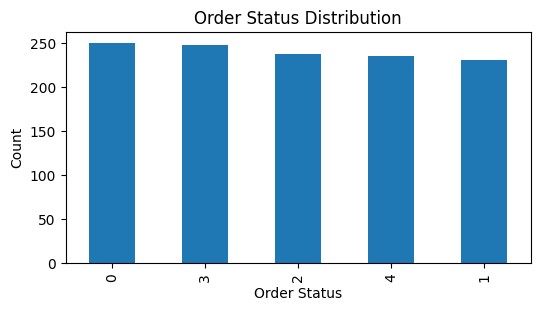

In [64]:
plt.figure(figsize=(6,3))

df["OrderStatus"].value_counts().plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.show()

In [65]:
X = df.drop("OrderStatus", axis=1)

y = df["OrderStatus"]

In [66]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 960
Testing Samples: 240


In [74]:
model = DecisionTreeClassifier(max_depth=4,random_state=42)

X_train['Date'] = pd.to_datetime(X_train['Date']).map(pd.Timestamp.toordinal)
X_test['Date'] = pd.to_datetime(X_test['Date']).map(pd.Timestamp.toordinal)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [75]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 15.83%


In [76]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 3 51  3  2  0]
 [ 8 25  6  2  0]
 [ 3 27  3  7  0]
 [ 3 30  3  7  0]
 [ 3 39  6  9  0]]


In [77]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.15      0.05      0.08        59
           1       0.15      0.61      0.23        41
           2       0.14      0.07      0.10        40
           3       0.26      0.16      0.20        43
           4       0.00      0.00      0.00        57

    accuracy                           0.16       240
   macro avg       0.14      0.18      0.12       240
weighted avg       0.13      0.16      0.11       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


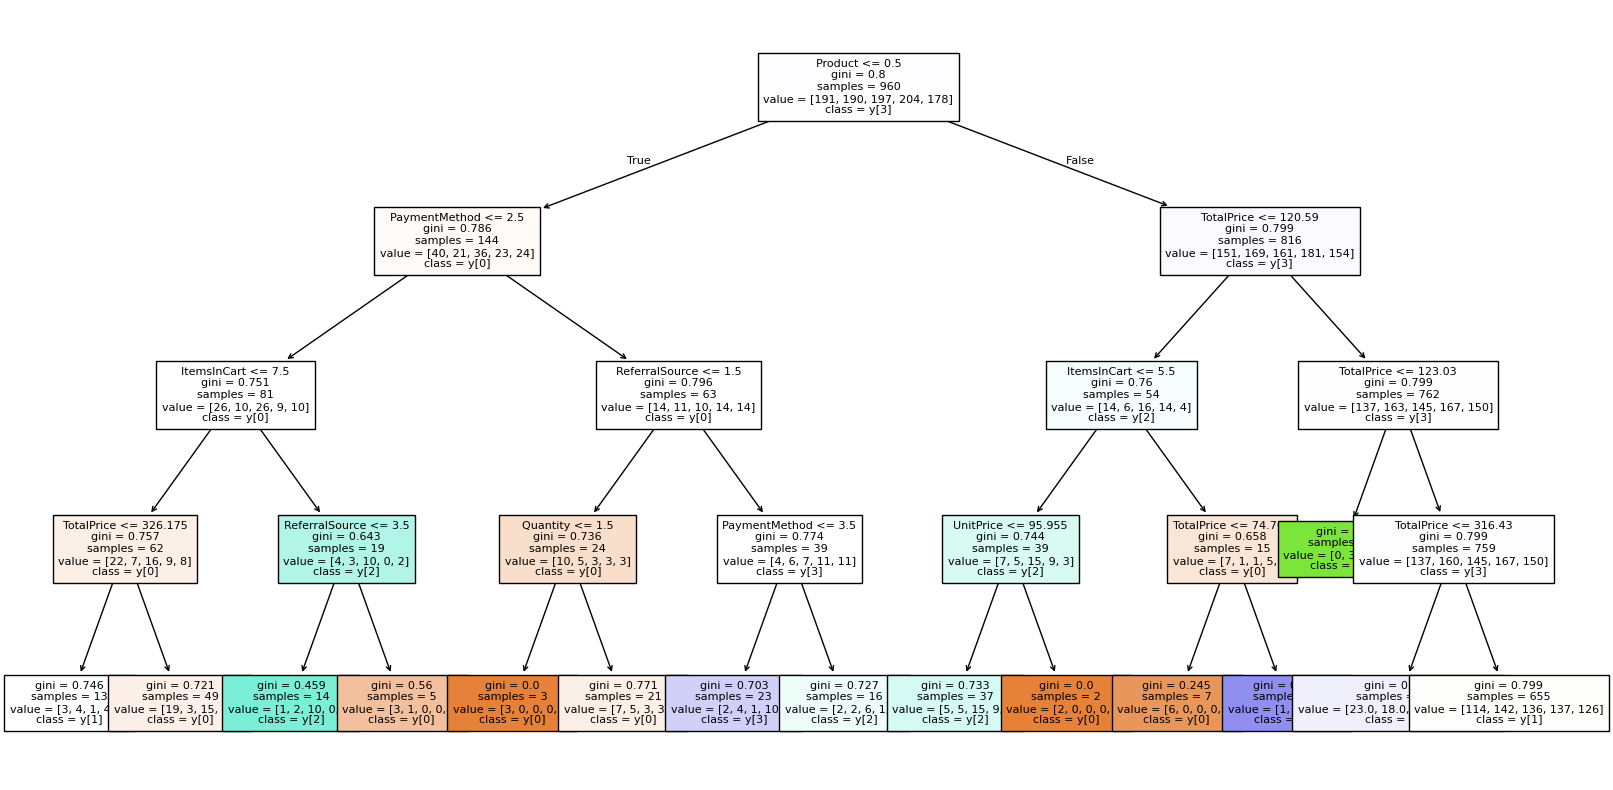

In [78]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    decision_tree=model,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    fontsize=8,
)

plt.show()

In [79]:
sample = X.iloc[[0]]
sample['Date'] = pd.to_datetime(sample['Date']).map(pd.Timestamp.toordinal)

prediction = model.predict(sample)

print("Predicted Order Status (Encoded):", prediction[0])

Predicted Order Status (Encoded): 1


/tmp/ipykernel_820/2085774251.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample['Date'] = pd.to_datetime(sample['Date']).map(pd.Timestamp.toordinal)
